# import modules

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn import preprocessing
import sys
import numpy as np
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import re
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,precision_recall_curve,PrecisionRecallDisplay,roc_curve,RocCurveDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Flatten
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping,History
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras import optimizers
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from matplotlib import pyplot as plt
import random
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import log_loss

# explore the dataset

In [ ]:
# upload data and other files
# from google.colab import files
# uploaded = files.upload()
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read data from csv file
df = pd.read_csv('/content/drive/MyDrive/IMDB_reviews.csv')
pd.options.display.max_colwidth = 5000
# print some rows
display(df.loc[0:1,:])
print("---------------------")
#sentiment count
print(df['sentiment'].value_counts())

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive


---------------------
positive    25000
negative    25000
Name: sentiment, dtype: int64


In [ ]:
# read data from csv file
# df = pd.read_csv('IMDB_reviews.csv')
# pd.options.display.max_colwidth = 5000
# # print some rows
# display(df.loc[0:1,:])
# print("---------------------")
# #sentiment count
# print(df['sentiment'].value_counts())

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


None

No missing data is in the data

# Cleaning and Standardization

In [ ]:
# replace html tags
df['review'] = df['review'].str.replace(r'<[^<>]*>', '', regex=True)
# convert strings to lower case
df['review'] = df['review'].str.lower()


In [ ]:
#Define function for removing special characters
def remove_special_characters(text, remove_digits=True):
    pattern=r'[^a-zA-z0-9\s]'
    text=re.sub(pattern,'',text)
    return text
#Apply function on review column
df['review']=df['review'].apply(remove_special_characters)

#Removing the square brackets
def remove_between_square_brackets(text):
    return re.sub('\[[^]]*\]', '', text)

#Removing the noisy text
def denoise_text(text):
    text = remove_between_square_brackets(text)
    return text
#Apply function on review column
df['review']=df['review'].apply(denoise_text)

# print some rows
display(df.loc[0:1,:])

,review,sentiment
0,one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,positive
1,a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done,positive


In [ ]:
import nltk
nltk.download('stopwords')
# remove stopwords
def remove_stopwords(df):
    # Downloading stop words
    stop_words = set(stopwords.words('english'))

    # Removing Stop words from training data
    count = 0
    for sentence in df:
        sentence = [word for word in sentence.lower().split() if word not in stop_words]
        sentence = ' '.join(sentence)
        df.loc[count] = sentence
        count+=1
    return(df)


df['review'] = remove_stopwords(df['review'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# removing emojies
# import emoji

# df["review"].apply(emoji.demojize)

# label encoding using scikit

In [ ]:
# print 5 examples of df lables
display(df["sentiment"].head())

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

In [ ]:
# use label encoding in scikit
le = preprocessing.LabelEncoder()
le.fit(df["sentiment"])
print(list(le.classes_))
df["sentiment"] = le.transform(df["sentiment"])
# print 5 examples of df lables
display(df["sentiment"].head())

['negative', 'positive']


0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

# split the dataset to train, dev, test

In [ ]:
# print columns available in dataset
display(df.columns)

Index(['review', 'sentiment'], dtype='object')

In [ ]:
# split the dataset into test and train
X_train, X_test, y_train, y_test = train_test_split(df.loc[:, ['review']], df.loc[:, ['sentiment']], test_size=0.25, random_state=42)

In [ ]:
# print the shape of train and test datasets
print(X_train.shape)
print(X_test.shape)


(37500, 1)
(12500, 1)


In [ ]:
display(X_train)
display(y_train)

,review
27434,figure alternate reality teen flickmore precisely ferris bueller type character leader cheat ring yeah know meant compared ferris bueller least orangestooranges way nonethelessbottomline galaxies away even even minor classic watchable though youre expecting much said main character charm premise wears thin writing isnt clever movie deliver enough laughs twists tension keep interest honest continue watchingwatching hopes see anything suddenly clicked didnt stylish wouldnt recommend movie btw seems odd see mary tyler moore principal shes truly miscast hope paycheck inordinately big
13400,kind movie wants good sucks first thing hell punk trying school think kids doesnt seem realize gravity situation deker guy say girl responsibility ask wants go back right gives gun wheel chair dude wants go alone repair phone line responsibility understand poor actors must pay food give money takes make stupid movie like give money charity oh yea none knows aim stupid punk guy shoots cafeteria nowhere like crazy want look professional suck one thing dont believe theres emergency exit school kids trying several doors locked happens theres fire dumass security guard dead illegal emergency exit school anyway theres lot say would long spent time life watch crap
883,far worst movie ive ever seen thats compared alexander fortress 2 new worldi go back blockbuster ask money back along compensation truly traumatic experience first ten minutes changing zoom widescreen tv actors seemed screen didnt think possible make bad film day age wrong typing message ive thought good reason buy movie joke present xmas im blaming mrs one picked thanks babebe warneda true shocker round
7303,awful awful awfuli loved original film funny charming heart piece junk none thingsreused jokes original film stupid plots bad animation different voices exception kronk yzma sound nothing like ones original especially pacha shudderthe characters model animation flat boring bad job aroundand kuzco jerk thought reformed since tv spin offs loyal original rolls eyesim sorry nothing redeemable allavoid costs
45124,fragile carne great period although sometimes hesitantly directed marred longueurs hotel du nord full faded charm beauty typical french films late 1930s well relative lightness touch unusual director great virtues cramped interiors broken gliding complex delicious camera movements melancholy deployment light shade remarkable wistful sets alexander trauner evocative title suggests take shaping personality quietly mournful music maurice jaubert seemingly casual plot romance tragedy fatalism casts noose characters extraordinary performances greatest players time case louis jouvet arlettyin fact films biggest failing find astonished someone usually didactically minimises importance admit script plenty wit poignancy without poetry irony regular carne collaborator jacques prevert brought best films cannot avoid slipping cliche even cliche hindsightostensibly set boarding house film sets opening idea community two interconnecting tales doomed love emotional metaphysical actual isolation doomed love scenario one works least well annabella beautiful good tragic aumonts callowness brilliantly appropriate though may nature obtrudes real felt romance maybe find hard sympathise couple young attractive months racked despair shoot highflown lines rather embarrassing course affair meant plausible symbolic youth hope possibility crushed france maybe france despairing resigned waiting death symbols truly powerful must convince narrative level feel dont quite herewhat saves plot connection story edmond character linked great tradition french gangsters although learn gradually killer hiding living prostitute played arletty dobbed accomplices previous role theatricality position crucial one set traits hiding assumed complete opposite living rather aimless life profoundly shaken lovers pact becomes fatalistic realising folly trying cheat deathin way admission one less person collection 

,sentiment
27434,0
13400,0
883,0
7303,0
45124,1
...,...
11284,1
44732,1
38158,0
860,1


# Tokenization and Padding

In [ ]:
# convert train datafarme to list of strings
train_data =X_train.astype(str).values.tolist()
train_data = [''.join(x) for x in train_data]
display(train_data[0:3])
print(len(train_data))

['figure alternate reality teen flickmore precisely ferris bueller type character leader cheat ring yeah know meant compared ferris bueller least orangestooranges way nonethelessbottomline galaxies away even even minor classic watchable though youre expecting much said main character charm premise wears thin writing isnt clever movie deliver enough laughs twists tension keep interest honest continue watchingwatching hopes see anything suddenly clicked didnt stylish wouldnt recommend movie btw seems odd see mary tyler moore principal shes truly miscast hope paycheck inordinately big',
 'kind movie wants good sucks first thing hell punk trying school think kids doesnt seem realize gravity situation deker guy say girl responsibility ask wants go back right gives gun wheel chair dude wants go alone repair phone line responsibility understand poor actors must pay food give money takes make stupid movie like give money charity oh yea none knows aim stupid punk guy shoots cafeteria nowhere li

37500


In [ ]:
# convert train datafarme to list of strings
test_data =X_test.astype(str).values.tolist()
test_data = [''.join(x) for x in test_data]
display(test_data[0:3])
print(len(test_data))

['really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslams ever wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man im glad times changed terrible main event like every match luger terrible matches card razor ramon vs ted dibiase steiner brothers vs heavenly bodies shawn michaels vs curt hening event shawn named big monster body guard diesel irs vs 123 kid bret hart first takes doink takes jerry lawler stuff harts lawler always interesting ludvig borga destroyed marty jannetty undertaker took giant gonzalez another terrible match smoking gunns tatanka took bam bam bigelow headshrinkers yokozuna defended world title lex luger match boring terrible ending however deserves 810',
 'many television shows appeal quite many different kinds fans like farscape doesi know youngsters 3040 years oldfans male female many different countries think adore tv miniseries elements found almost every show tv character driven 

12500


In [ ]:
vocab_size = 10000
def tokenize(data,test_data):
  num_words = vocab_size
  oov_token = '<UNK>'
  pad_type = 'post'
  trunc_type = 'post'
  tokenizer = Tokenizer(num_words=num_words, oov_token=oov_token)
  tokenizer.fit_on_texts(data)

  # Get our training data word index
  word_index = tokenizer.word_index

  # Encode training data sentences into sequences
  train_sequences = tokenizer.texts_to_sequences(data)
  test_sequences = tokenizer.texts_to_sequences(test_data)

  # Get max training sequence length
  maxlen = max([len(x) for x in train_sequences])

  # Pad the training sequences
  train_padded = pad_sequences(train_sequences, padding=pad_type, truncating=trunc_type, maxlen=maxlen)
  # Pad the training sequences
  test_padded = pad_sequences(test_sequences, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

  # Output the results of our work
  # print("Word index:\n", word_index)
  print("\nTraining sequences:\n", train_sequences[0:4])
  print("\nPadded training sequences:\n", train_padded[0:4])
  print("\nPadded training shape:", train_padded.shape)
  print("Training sequences data type:", type(train_sequences))
  print("Padded Training sequences data type:", type(train_padded))
  print("----------------------------------------")
  print("\nTraining sequences:\n", test_sequences[0:4])
  print("\nPadded training sequences:\n", test_padded[0:4])
  print("\nPadded training shape:", test_padded.shape)
  print("Training sequences data type:", type(test_sequences))
  print("Padded Training sequences data type:", type(test_padded))
  return train_padded,test_padded,maxlen

In [ ]:
# tokenize train set
X_train_tok, X_test_tok,maxlen = tokenize(train_data,test_data);


Training sequences:
 [[712, 4616, 509, 1351, 1, 5128, 1, 1, 465, 33, 1713, 7713, 1656, 1039, 41, 846, 963, 1, 1, 115, 1, 27, 1, 1, 142, 7, 7, 1214, 247, 1613, 64, 220, 875, 13, 197, 165, 33, 1265, 704, 2567, 1583, 374, 107, 890, 2, 1495, 94, 810, 1093, 1005, 265, 494, 1015, 1435, 1, 1661, 11, 131, 949, 1, 60, 2906, 431, 251, 2, 6195, 87, 901, 11, 1244, 4555, 1900, 4062, 334, 248, 2987, 310, 8283, 1, 96], [138, 2, 366, 6, 1559, 20, 59, 426, 3708, 154, 272, 29, 222, 58, 195, 794, 7452, 756, 1, 121, 48, 150, 4284, 813, 366, 53, 54, 113, 282, 910, 6463, 2835, 2423, 366, 53, 510, 9846, 1425, 260, 4284, 269, 218, 61, 109, 881, 1544, 98, 184, 188, 25, 258, 2, 5, 98, 184, 7910, 358, 1, 511, 557, 4893, 258, 3708, 121, 3005, 1, 1116, 5, 871, 84, 71, 1537, 2579, 4, 59, 21, 152, 125, 8509, 6261, 272, 222, 154, 314, 3159, 2914, 421, 125, 876, 1, 2397, 2880, 250, 3636, 8509, 6261, 272, 559, 125, 72, 48, 8, 103, 841, 9, 44, 30, 497], [127, 140, 2, 100, 43, 31, 83, 963, 3426, 1, 196, 73, 1, 53, 54, 2

# this method evaluates the models

In [ ]:
# Function to evaluate the model
def model_evaluation(model, X_train, y_train, X_test, y_test):
    # Fit the model
    # model.fit(X_train, y_train)
    # Predict the model
    print("-----------------------------------------")
    print("train set evaluation")
    print("-----------------------------------------")
    y_pred = model.predict(X_train)
    # Model Evaluation
    print('Accuracy Score: ', accuracy_score(y_train, y_pred))
    print('Precision Score: ', precision_score(y_train, y_pred))
    print('Recall Score: ', recall_score(y_train, y_pred))
    print('F1 Score: ', f1_score(y_train, y_pred))
    print('Confusion Matrix: ', confusion_matrix(y_train, y_pred))
    print('Classification Report: ', classification_report(y_train, y_pred))
    fig, axs = plt.subplots(ncols=2)
    sns.heatmap(confusion_matrix(y_train, y_pred),
            annot=True, fmt='.0f',
            xticklabels=['Predicted negative', 'Predicted positive'],
            yticklabels=['Negative', 'Positive'], ax=axs[0])
    print("-----------------------------------------")
    print("test set evaluation")
    print("-----------------------------------------")
    y_pred = model.predict(X_test)
    print(y_pred.shape)
    print(y_test.shape)
    # Model Evaluation
    print('Accuracy Score: ', accuracy_score(y_test, y_pred))
    print('Precision Score: ', precision_score(y_test, y_pred))
    print('Recall Score: ', recall_score(y_test, y_pred))
    print('F1 Score: ', f1_score(y_test, y_pred))
    print('Confusion Matrix: ', confusion_matrix(y_test, y_pred))
    print('Classification Report: ', classification_report(y_test, y_pred))


    sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='.0f',
            xticklabels=['Predicted negative', 'Predicted positive'],
            yticklabels=['Negative', 'Positive'], ax=axs[1])

# logistic regression

In [ ]:
y_train = np.ravel(y_train)
print(y_train.shape)
y_test = np.ravel(y_test)
print(y_test.shape)

(37500,)
(12500,)


In [ ]:
logistic_clf = LogisticRegression(random_state=0,max_iter = 1000).fit(X_train_tok, y_train)

In [ ]:
print(logistic_clf.predict(X_train_tok[:2, :]))
print(logistic_clf.predict_proba(X_train_tok[:2, :]))
print(logistic_clf.score(X_train_tok, y_train))
print(logistic_clf.coef_)

[1 0]
[[0.47562505 0.52437495]
 [0.53965806 0.46034194]]
0.5400533333333334
[[1.16975532e-05 6.61467771e-06 1.56104019e-05 ... 2.84627249e-06
  1.20178675e-07 1.22631301e-09]]


### evaluate the logistic regression model

-----------------------------------------
train set evaluation
-----------------------------------------
Accuracy Score:  0.5400533333333334
Precision Score:  0.5310831678799912
Recall Score:  0.6451733933644208
F1 Score:  0.5825952277237307
Confusion Matrix:  [[ 8215 10628]
 [ 6620 12037]]
Classification Report:                precision    recall  f1-score   support

           0       0.55      0.44      0.49     18843
           1       0.53      0.65      0.58     18657

    accuracy                           0.54     37500
   macro avg       0.54      0.54      0.54     37500
weighted avg       0.54      0.54      0.53     37500

-----------------------------------------
test set evaluation
-----------------------------------------
(12500,)
(12500,)
Accuracy Score:  0.51384
Precision Score:  0.5176158940397351
Recall Score:  0.6161122497241053
F1 Score:  0.5625854746994888
Confusion Matrix:  [[2515 3642]
 [2435 3908]]
Classification Report:                precision    recall  f1-s

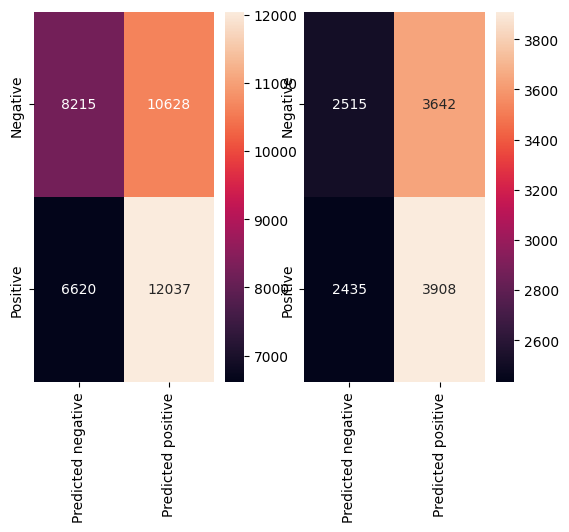

In [ ]:
# evaluate the model and print scores
model_evaluation(logistic_clf, X_train_tok, y_train, X_test_tok, y_test)

### using tfidf

In [ ]:
vectorizer = TfidfVectorizer()
# fit and vectorize on train data
logistic_vectorized_train = vectorizer.fit_transform(train_data)
# vectorize the test data
logistic_vectorized_test = vectorizer.transform(test_data)


In [ ]:
feature_names =vectorizer.get_feature_names_out()
print(feature_names)
print(logistic_vectorized_train.shape)

['00' '000' '00000001' ... 'zzzzzzzzzzzzz' 'zzzzzzzzzzzzzzzzzz'
 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz']
(37500, 184548)


In [ ]:
# run logistic regression using tfidf
logistic_tfidf_clf = LogisticRegression(random_state=0,max_iter = 10000).fit(logistic_vectorized_train, y_train)
# predict the labels of first 2 rows of train set
print(logistic_tfidf_clf.predict(logistic_vectorized_train[:2, :]))
# predict the prrobabilities of labels of first 2 rows of train set
print(logistic_tfidf_clf.predict_proba(logistic_vectorized_train[:2, :]))
# compute the score on train set
print(logistic_tfidf_clf.score(logistic_vectorized_train, y_train))

[0 0]
[[0.85646611 0.14353389]
 [0.96378513 0.03621487]]
0.9369066666666667


### evaluate the logistic regression model

-----------------------------------------
train set evaluation
-----------------------------------------
Accuracy Score:  0.9369066666666667
Precision Score:  0.930591531426759
Recall Score:  0.9435600578871202
F1 Score:  0.9370309256400703
Confusion Matrix:  [[17530  1313]
 [ 1053 17604]]
Classification Report:                precision    recall  f1-score   support

           0       0.94      0.93      0.94     18843
           1       0.93      0.94      0.94     18657

    accuracy                           0.94     37500
   macro avg       0.94      0.94      0.94     37500
weighted avg       0.94      0.94      0.94     37500

-----------------------------------------
test set evaluation
-----------------------------------------
(12500,)
(12500,)
Accuracy Score:  0.89688
Precision Score:  0.8899691358024692
Recall Score:  0.909191234431657
F1 Score:  0.8994775013647353
Confusion Matrix:  [[5444  713]
 [ 576 5767]]
Classification Report:                precision    recall  f1-sco

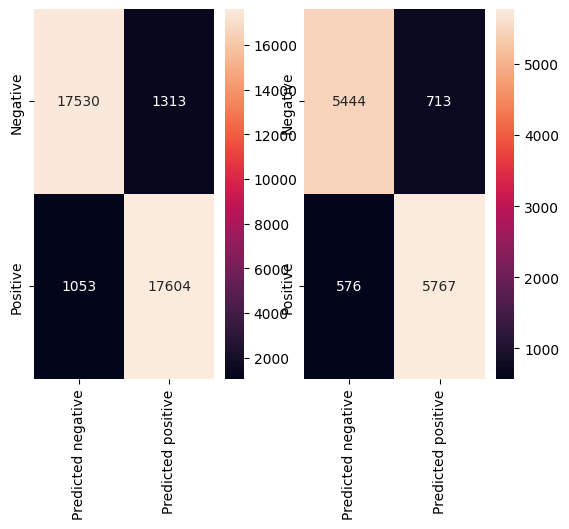

In [ ]:
# evaluate the model and print scores
model_evaluation(logistic_tfidf_clf, logistic_vectorized_train, y_train, logistic_vectorized_test, y_test)

# naive bayes approach

### preprocessing the data for naive bayes approach

In [ ]:
naive_bayes_vectorizer = CountVectorizer(max_features=20000)
naive_bayes_train_vectorized = naive_bayes_vectorizer.fit_transform(train_data)
print(naive_bayes_vectorizer.get_feature_names_out())

['007' '010' '05' ... 'zu' 'zucco' 'zucker']


In [ ]:
naive_bayes_test_vectorized = naive_bayes_vectorizer.transform(test_data)

### train the naive bayes model

In [ ]:
# use naive bayes model
naive_bayes_clf = MultinomialNB(force_alpha=True)
# train the model
naive_bayes_clf.fit(naive_bayes_train_vectorized, y_train)
# predict the labels of first 2 rows
print(naive_bayes_clf.predict(naive_bayes_train_vectorized[0:2]))

[0 0]


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### evaluate the naive bayes model

-----------------------------------------
train set evaluation
-----------------------------------------
Accuracy Score:  0.8757866666666667
Precision Score:  0.8868195634153081
Recall Score:  0.8601061263868789
F1 Score:  0.873258598171528
Confusion Matrix:  [[16795  2048]
 [ 2610 16047]]
Classification Report:                precision    recall  f1-score   support

           0       0.87      0.89      0.88     18843
           1       0.89      0.86      0.87     18657

    accuracy                           0.88     37500
   macro avg       0.88      0.88      0.88     37500
weighted avg       0.88      0.88      0.88     37500

-----------------------------------------
test set evaluation
-----------------------------------------
(12500,)
(12500, 1)
Accuracy Score:  0.85536
Precision Score:  0.8693598305913015
Recall Score:  0.8413999684691786
F1 Score:  0.8551514180419805
Confusion Matrix:  [[5355  802]
 [1006 5337]]
Classification Report:                precision    recall  f1-

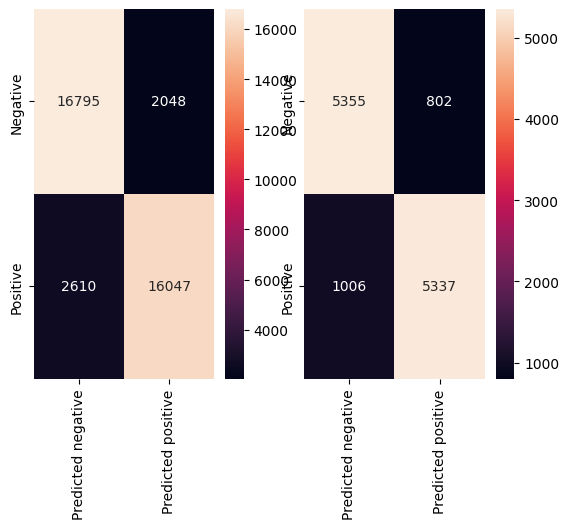

In [ ]:
# evaluate the model and print scores
model_evaluation(naive_bayes_clf, naive_bayes_train_vectorized, y_train, naive_bayes_test_vectorized, y_test)

# LSTM model approach

### split training data into train and dev sets

In [ ]:
# split the training set into dev and train
X_train_nn, X_dev_nn, y_train_nn, y_dev_nn = train_test_split(X_train_tok, y_train, test_size=0.25, random_state=42)

In [ ]:
y_train_nn.shape

(28125, 1)

In [ ]:
y_dev_nn.shape

(9375, 1)

### creating the layers of lstm

In [ ]:
# creat the architecture of th model with the best parameters
def create_model():
  lstm_model = Sequential()
  lstm_model.add(Embedding(vocab_size, 64, input_length = maxlen, mask_zero=True))
  lstm_model.add(SpatialDropout1D(0.2))
  lstm_model.add(LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2))
  lstm_model.add(Flatten())
  lstm_model.add(Dense(units=1, activation='sigmoid'))

  print(lstm_model.summary())
  return lstm_model

### train the model with early stopping

In [ ]:
# Define the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)

In [ ]:
resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='')
tf.config.experimental_connect_to_cluster(resolver)
# This is the TPU initialization code that has to be at the beginning.
tf.tpu.experimental.initialize_tpu_system(resolver)
print("All devices: ", tf.config.list_logical_devices('TPU'))
strategy = tf.distribute.TPUStrategy(resolver)

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: grpc://10.124.130.234:8470
INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:worker/replica:0/task:0/device:TPU:

All devices:  [LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:0', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:1', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:2', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:3', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:4', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:5', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:6', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:7', device_type='TPU')]


In [ ]:
with strategy.scope():
  lstm_model = create_model()
  lstm_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
# Train the model with early stopping
history = lstm_model.fit(X_train_nn,
                    y_train_nn,
                    epochs=5,
                    batch_size=64,
                    validation_data=(X_dev_nn, y_dev_nn),
                    callbacks=[early_stopping])

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_16 (Embedding)    (None, 1429, 64)          640000    
                                                                 
 spatial_dropout1d_16 (Spati  (None, 1429, 64)         0         
 alDropout1D)                                                    
                                                                 
 lstm_16 (LSTM)              (None, 32)                12416     
                                                                 
 flatten_16 (Flatten)        (None, 32)                0         
                                                                 
 dense_16 (Dense)            (None, 1)                 33        
                                                                 
Total params: 652,449
Trainable params: 652,449
Non-trainable params: 0
_______________________________________________

In [ ]:
print(history.history.keys())
print(history.history['val_loss'])

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
[0.2959187924861908, 0.27666425704956055, 0.32215645909309387, 0.3223184049129486, 0.3734157383441925]


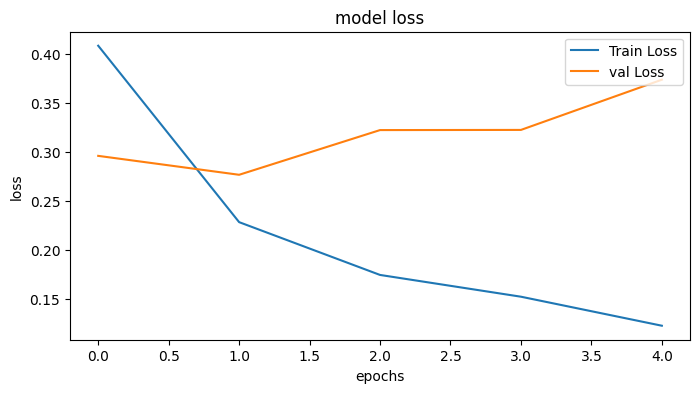

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='val Loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper right')
plt.show();

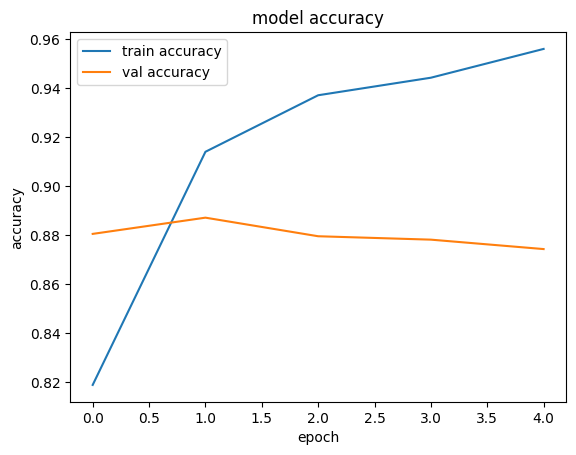

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'val accuracy'], loc='upper left')
plt.show()

In [ ]:
# compute model's accuracy on train dataset
scores = lstm_model.evaluate(X_train_tok, y_train, verbose=1)
scores[1]

1172/1172 [==============================] - 47s 39ms/step - loss: 0.1537 - accuracy: 0.9499


0.9498933553695679

In [ ]:
# compute model's accuracy on dev dataset
scores = lstm_model.evaluate(X_dev_nn, y_dev_nn, verbose=1)
scores[1]

293/293 [==============================] - 12s 39ms/step - loss: 0.3734 - accuracy: 0.8743


0.8743466734886169

In [ ]:
# compute model's accuracy on test dataset
scores = lstm_model.evaluate(X_test_tok, y_test, verbose=1)
scores[1]

391/391 [==============================] - 17s 42ms/step - loss: 0.3690 - accuracy: 0.8737


0.8736799955368042

In [ ]:
y_pred = lstm_model.predict(X_test_tok)
classes_x=y_pred>0.5

391/391 [==============================] - 15s 34ms/step


Accuracy Score:  0.87368
Precision Score:  0.8952870892797876
Recall Score:  0.8505439066687687
F1 Score:  0.8723421456867977
Confusion Matrix:  [[5526  631]
 [ 948 5395]]
Classification Report:                precision    recall  f1-score   support

           0       0.85      0.90      0.87      6157
           1       0.90      0.85      0.87      6343

    accuracy                           0.87     12500
   macro avg       0.87      0.87      0.87     12500
weighted avg       0.87      0.87      0.87     12500



<Axes: >

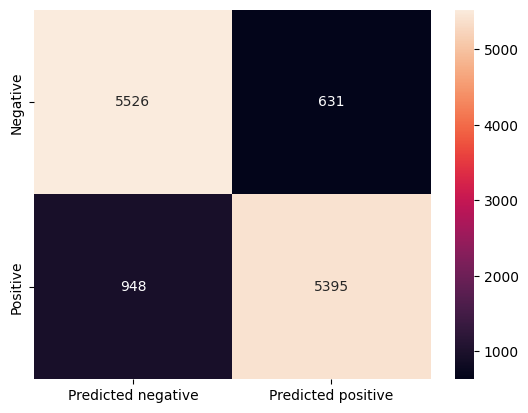

In [ ]:
print('Accuracy Score: ', accuracy_score(y_test, classes_x))
print('Precision Score: ', precision_score(y_test, classes_x))
print('Recall Score: ', recall_score(y_test, classes_x))
print('F1 Score: ', f1_score(y_test, classes_x))
print('Confusion Matrix: ', confusion_matrix(y_test, classes_x))
print('Classification Report: ', classification_report(y_test, classes_x))


sns.heatmap(confusion_matrix(y_test, classes_x),
        annot=True, fmt='.0f',
        xticklabels=['Predicted negative', 'Predicted positive'],
        yticklabels=['Negative', 'Positive'])

### parameter tuning

In [ ]:
from sklearn.model_selection import ShuffleSplit
param_grid = dict(units= [8,32,64], drop_out=[0.05, 0.2],batch_size=[64,128])

def create_model(drop_out,units):
  # creat the architecture of th model
  lstm_model = Sequential()
  lstm_model.add(Embedding(vocab_size, 64, input_length = maxlen, mask_zero=True))
  lstm_model.add(SpatialDropout1D(drop_out))
  lstm_model.add(LSTM(units, return_sequences=False, dropout=drop_out, recurrent_dropout=drop_out))
  lstm_model.add(Flatten())
  lstm_model.add(Dense(units=1, activation='sigmoid'))
  early_stopping = EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)
  optimizer = optimizers.Adam(learning_rate=0.0001)
  lstm_model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
  return lstm_model

with strategy.scope():
  model = KerasClassifier(build_fn=create_model)
  grid_clf = GridSearchCV(estimator=model, param_grid=param_grid, cv=ShuffleSplit(n_splits=1, random_state=0, test_size=0.2),scoring="accuracy")

history = History()


grid_result = grid_clf.fit(X_train_nn,
                    y_train_nn,
                    epochs=5,
                    validation_data=(X_dev_nn, y_dev_nn),
                    callbacks=[early_stopping,history])
print(grid_clf.best_params_)
print(grid_clf.score(X_train_nn, y_train_nn))

<ipython-input-50-62e4fee68ac5>:18: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_model)


Epoch 1/5
352/352 [==============================] - 326s 912ms/step - loss: 0.6845 - accuracy: 0.6555 - val_loss: 0.6549 - val_accuracy: 0.7306
Epoch 2/5
352/352 [==============================] - 318s 903ms/step - loss: 0.5256 - accuracy: 0.8172 - val_loss: 0.4799 - val_accuracy: 0.8341
Epoch 3/5
352/352 [==============================] - 318s 903ms/step - loss: 0.4491 - accuracy: 0.8616 - val_loss: 0.4514 - val_accuracy: 0.8363
Epoch 4/5
352/352 [==============================] - 319s 907ms/step - loss: 0.4113 - accuracy: 0.8747 - val_loss: 0.4382 - val_accuracy: 0.8415
Epoch 5/5
176/176 [==============================] - 17s 93ms/step
Epoch 1/5
352/352 [==============================] - 351s 984ms/step - loss: 0.6441 - accuracy: 0.6633 - val_loss: 0.5317 - val_accuracy: 0.8000
Epoch 2/5
352/352 [==============================] - 346s 983ms/step - loss: 0.4893 - accuracy: 0.8229 - val_loss: 0.4592 - val_accuracy: 0.8247
Epoch 3/5
352/352 [==============================] - 346s 984ms

In [ ]:
df_result = pd.DataFrame(grid_clf.cv_results_)

In [ ]:
display(df_result)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_drop_out,param_units,params,split0_test_score,mean_test_score,std_test_score,rank_test_score
0,1602.684120,0.0,17.178484,0.0,64,0.05,8,"{'batch_size': 64, 'drop_out': 0.05, 'units': 8}",0.837333,0.837333,0.0,12
1,1738.121702,0.0,20.930522,0.0,64,0.05,32,"{'batch_size': 64, 'drop_out': 0.05, 'units': 32}",0.873600,0.873600,0.0,6
2,1865.435393,0.0,25.118201,0.0,64,0.05,64,"{'batch_size': 64, 'drop_out': 0.05, 'units': 64}",0.878578,0.878578,0.0,5
3,1609.976807,0.0,16.397955,0.0,64,0.2,8,"{'batch_size': 64, 'drop_out': 0.2, 'units': 8}",0.869511,0.869511,0.0,9
4,1731.924829,0.0,21.452895,0.0,64,0.2,32,"{'batch_size': 64, 'drop_out': 0.2, 'units': 32}",0.886756,0.886756,0.0,1
5,1854.786997,0.0,24.930365,0.0,64,0.2,64,"{'batch_size': 64, 'drop_out': 0.2, 'units': 64}",0.886400,0.886400,0.0,2
6,866.656009,0.0,16.889863,0.0,128,0.05,8,"{'batch_size': 128, 'drop_out': 0.05, 'units': 8}",0.849244,0.849244,0.0,11
7,951.448055,0.0,20.613302,0.0,128,0.05,32,"{'batch_size': 128, 'drop_out': 0.05, 'units': 32}",0.871644,0.871644,0.0,7
8,1095.462787,0.0,24.313765,0.0,128,0.05,64,"{'batch_size': 128, 'drop_out': 0.05, 'units': 64}",0.870933,0.870933,0.0,8
9,859.994021,0.0,16.742642,0.0,128,0.2,8,"{'batch_size': 128, 'drop_out': 0.2, 'units': 8}",0.862044,0.862044,0.0,10


# clustering with K-means

In [ ]:
# train the model for clustering the data
kmeans = KMeans(n_clusters=2, random_state=0, n_init=100).fit(logistic_vectorized_train)
print(kmeans.labels_)
print("---------------------------")
print(kmeans.cluster_centers_)

[0 1 1 ... 1 0 1]
---------------------------
[[1.05591381e-05 6.43520937e-06 7.23670111e-06 ... 0.00000000e+00
  8.09640164e-06 5.76096200e-06]
 [3.30375387e-05 0.00000000e+00 0.00000000e+00 ... 1.82215803e-05
  0.00000000e+00 0.00000000e+00]]


### evaluate the model

In [ ]:
clusters = kmeans.labels_.tolist()
len(clusters)

37500

In [ ]:

product = { 'review': np.ravel(X_train), 'cluster': clusters}
frame = pd.DataFrame(product, columns = ['review', 'cluster'])
frame.head(10)

,review,cluster
0,figure alternate reality teen flickmore precisely ferris bueller type character leader cheat ring yeah know meant compared ferris bueller least orangestooranges way nonethelessbottomline galaxies away even even minor classic watchable though youre expecting much said main character charm premise wears thin writing isnt clever movie deliver enough laughs twists tension keep interest honest continue watchingwatching hopes see anything suddenly clicked didnt stylish wouldnt recommend movie btw seems odd see mary tyler moore principal shes truly miscast hope paycheck inordinately big,0
1,kind movie wants good sucks first thing hell punk trying school think kids doesnt seem realize gravity situation deker guy say girl responsibility ask wants go back right gives gun wheel chair dude wants go alone repair phone line responsibility understand poor actors must pay food give money takes make stupid movie like give money charity oh yea none knows aim stupid punk guy shoots cafeteria nowhere like crazy want look professional suck one thing dont believe theres emergency exit school kids trying several doors locked happens theres fire dumass security guard dead illegal emergency exit school anyway theres lot say would long spent time life watch crap,1
2,far worst movie ive ever seen thats compared alexander fortress 2 new worldi go back blockbuster ask money back along compensation truly traumatic experience first ten minutes changing zoom widescreen tv actors seemed screen didnt think possible make bad film day age wrong typing message ive thought good reason buy movie joke present xmas im blaming mrs one picked thanks babebe warneda true shocker round,1
3,awful awful awfuli loved original film funny charming heart piece junk none thingsreused jokes original film stupid plots bad animation different voices exception kronk yzma sound nothing like ones original especially pacha shudderthe characters model animation flat boring bad job aroundand kuzco jerk thought reformed since tv spin offs loyal original rolls eyesim sorry nothing redeemable allavoid costs,0
4,fragile carne great period although sometimes hesitantly directed marred longueurs hotel du nord full faded charm beauty typical french films late 1930s well relative lightness touch unusual director great virtues cramped interiors broken gliding complex delicious camera movements melancholy deployment light shade remarkable wistful sets alexander trauner evocative title suggests take shaping personality quietly mournful music maurice jaubert seemingly casual plot romance tragedy fatalism casts noose characters extraordinary performances greatest players time case louis jouvet arlettyin fact films biggest failing find astonished someone usually didactically minimises importance admit script plenty wit poignancy without poetry irony regular carne collaborator jacques prevert brought best films cannot avoid slipping cliche even cliche hindsightostensibly set boarding house film sets opening idea community two interconnecting tales doomed love emotional metaphysical actual isolation doomed love scenario one works least well annabella beautiful good tragic aumonts callowness brilliantly appropriate though may nature obtrudes real felt romance maybe find hard sympathise couple young attractive months racked despair shoot highflown lines rather embarrassing course affair meant plausible symbolic youth hope possibility crushed france maybe france despairing resigned waiting death symbols truly powerful must convince narrative level feel dont quite herewhat saves plot connection story edmond character linked great tradition french gangsters although learn gradually killer hiding living prostitute played arletty dobbed accomplices previous role theatricality position crucial one set traits hiding assumed complete opposite living rather aimless life profoundly shaken lovers pact becomes fatalistic realising folly trying cheat deathin way admission one less person collection s

In [ ]:
# importances of each items in centroid We need to sort it in decreasing-order and get the top k items
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

Cluster_keywords_summary = {}
for i in range(2):
    print ("Cluster " + str(i) + " words:", end='')
    Cluster_keywords_summary[i] = []
    for ind in order_centroids[i, :5]: #5 words per cluster
        Cluster_keywords_summary[i].append(feature_names[ind])
        print (feature_names[ind] + ",", end='')
    print ()

    cluster_reviews = frame[frame.cluster==i].review.tolist()
    print ("Cluster " + str(i) + " reviews (" + str(len(cluster_reviews)) + " reviews): ")

Cluster 0 words:film,one,movie,like,good,
Cluster 0 reviews (27122 reviews): 
Cluster 1 words:movie,like,bad,movies,one,
Cluster 1 reviews (10378 reviews): 


-----------------------------------------
train set evaluation
-----------------------------------------
Accuracy Score:  0.4277066666666667
Precision Score:  0.36490653305068416
Recall Score:  0.20298011470225652
F1 Score:  0.26085758567246425
Confusion Matrix:  [[12252  6591]
 [14870  3787]]
Classification Report:                precision    recall  f1-score   support

           0       0.45      0.65      0.53     18843
           1       0.36      0.20      0.26     18657

    accuracy                           0.43     37500
   macro avg       0.41      0.43      0.40     37500
weighted avg       0.41      0.43      0.40     37500

-----------------------------------------
test set evaluation
-----------------------------------------
(12500,)
(12500,)
Accuracy Score:  0.41552
Precision Score:  0.3679736769947902
Recall Score:  0.21157181144568815
F1 Score:  0.2686686686686687
Confusion Matrix:  [[3852 2305]
 [5001 1342]]
Classification Report:                precision    recall  

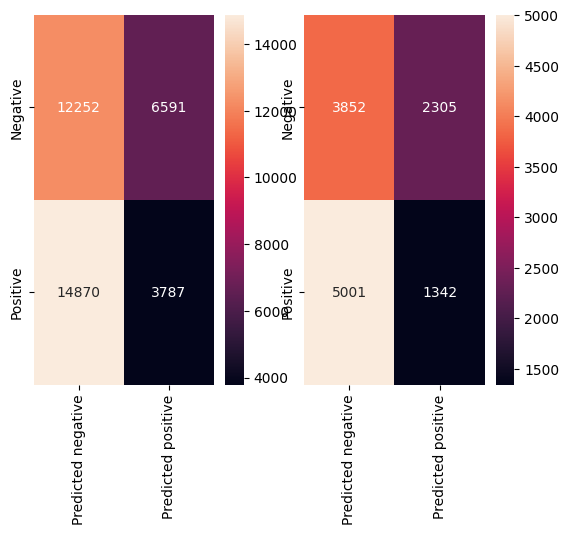

In [ ]:
# evaluate the model and print scores
model_evaluation(kmeans, logistic_vectorized_train, y_train, logistic_vectorized_test, y_test)

# inference

In [ ]:
# sampling 3 random examples from test set without replacement
rand_nums = random.sample(range(0, len(X_test_tok)), 3)
print(rand_nums)

[801, 12437, 3095]


In [ ]:
for i in rand_nums:
  print(f"example number {i}: ")
  # actual labels
  print(f"actual label : {y_test[i]}")
  # prediction with LSTM
  x = np.expand_dims(X_test_tok[i, :], 0)
  print(f"lstm prediction : {int(lstm_model.predict(x)>0.5)}")
  # prediction with naive bayes model
  print(f"naive bayes prediction : {naive_bayes_clf.predict(naive_bayes_test_vectorized[i, :])}")
  # prediction with tfidf logistic regression model
  print(f"tfidf logistic regression prediction : {logistic_tfidf_clf.predict(logistic_vectorized_test[i, :])}")
  # prediction with logistic regression model
  print(f"logistic regression prediction (note that logistic regression performs poorly compared to tfidf logistic regression): {logistic_clf.predict(X_train_tok[i, :].reshape(1, -1))}")
  print("-----------------------------------------------")

example number 801: 
actual label : 0
1/1 [==============================] - 1s 1s/step
lstm prediction : 0
naive bayes prediction : [0]
tfidf logistic regression prediction : [0]
logistic regression prediction (note that logistic regression performs poorly compared to tfidf logistic regression): [1]
-----------------------------------------------
example number 12437: 
actual label : 1
1/1 [==============================] - 1s 596ms/step
lstm prediction : 1
naive bayes prediction : [1]
tfidf logistic regression prediction : [1]
logistic regression prediction (note that logistic regression performs poorly compared to tfidf logistic regression): [1]
-----------------------------------------------
example number 3095: 
actual label : 1
1/1 [==============================] - 1s 579ms/step
lstm prediction : 1
naive bayes prediction : [1]
tfidf logistic regression prediction : [1]
logistic regression prediction (note that logistic regression performs poorly compared to tfidf logistic regres